# Introduction to GETELEC

A guided tour, from `import getelec` to fitting experimental data. Run the
cells in order; each one builds on the last.

**What GETELEC computes.** How many electrons escape a surface under a strong
electric field, at a given temperature. For a metal the current density is an
integral over electron energy,

$$ J = e \int N(E)\, D(E)\, \mathrm{d}E $$

with two factors that carry quite different physics:

- $D(E)$, the **transmission coefficient** — the chance an electron of energy
  $E$ gets through the surface barrier. Set by the barrier: work function,
  field, tip shape. Independent of temperature.
- $N(E)$, the **supply function** — how many electrons arrive at the surface per
  unit energy. Set by the occupancy: Fermi level and temperature. Independent of
  the barrier.

**Contents.** 0 Installation · 1 Units · 2 The one-liner · 3 The emitter ·
4 Calculations · 5 Changing the emitter · 6 Choosing a solver · 7 Checking the
answer · 8 Semiconductors · 9 Sharp tips and the neural solver · 10 The
wavefunction · 11 Full control · 12 Fitting experimental data · 13 What a fit
can and cannot tell you · 14 A tabulated density of states · 15 Your own barrier

## 0. Installation

In a virtual environment, either with pip, in a folder that also holds this
notebook and its three data files, `iv.txt`, `ted.txt` and `dos.txt`:

```bash
python -m venv .venv
source .venv/bin/activate          # Windows: .\.venv\Scripts\Activate.ps1
pip install getelec matplotlib ipykernel
```

or from GitHub, from the repository root, where the notebook is in `examples/`:

```bash
python -m venv .venv
source .venv/bin/activate          # Windows: .\.venv\Scripts\Activate.ps1
pip install -e ".[dev]"
```

The notebook has to run on that environment:

- **VS Code:** click **Select Kernel** (top right) → **Python Environments** →
  the one whose path contains `.venv`. VS Code remembers the choice.
  If `.venv` is not in that list, give VS Code its path by hand: **Select
  Kernel** → **Create Python Environment** → **Enter interpreter path** →
  the project folder (`GETELEC`) → `.venv` → `Scripts` → `python.exe`
  (macOS/Linux: `.venv/bin/python`). Scroll down the file list to find it;
  Windows may show it as just `python`, of type Application.
- **Browser:** start Jupyter from a terminal where `.venv` is active, with
  `jupyter notebook` followed by the path to this notebook (with pip, install
  `notebook` first). It then uses that environment automatically.

The next cell checks this and says what to do if it is wrong. `INSTALL.md` has a
walkthrough for both ways that assumes nothing.

In [1]:
import sys
import time

try:
    import getelec
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "getelec is not installed in the Python running this notebook:\n"
        f"    {sys.executable}\n"
        "Select the project's .venv as the kernel (VS Code: 'Select Kernel', top "
        "right), or start Jupyter from a terminal where .venv is active. "
        "See INSTALL.md."
    ) from None

import numpy as np
import matplotlib.pyplot as plt

print("GETELEC version:", getelec.__version__)

GETELEC version: 3.1.0


## 1. Units — read this once

| quantity | unit |
|---|---|
| energy, work function, Fermi level | eV |
| distance, tip radius | nm |
| electric field | V/nm |
| temperature | K |
| current density $J$ | A/cm² |
| Nottingham heat $P_N$ | W/cm² |
| distributions | A/(eV·cm²) |

Field emission happens around **3–10 V/nm**, which is
3–10 × 10⁹ V/m. If you enter 5×10⁹ you will get zero current and no error.

## 2. The one-liner

For a single number you do not need an object at all.

In [2]:
j = getelec.current_density(field=5.0, work_function=4.5, fermi_level=7.5,
                            temperature=300.0)
print(f"J = {j:.4e} A/cm^2")

J = 4.0874e+05 A/cm^2


Any argument accepts an array, and the whole set is solved in one pass rather
than a Python loop — two arrays broadcast into a grid. This is the
Fowler–Nordheim behaviour: the current rises almost vertically with field.

field x temperature grid: (40, 3)


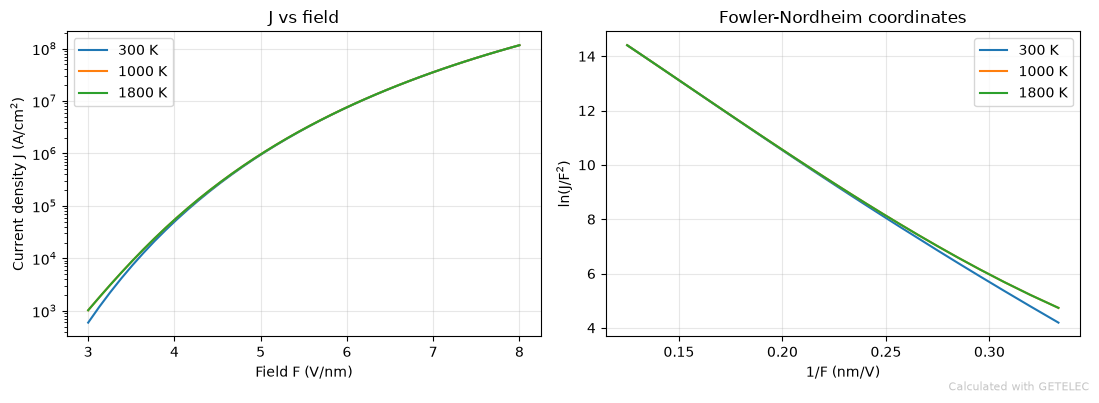

In [3]:
fields = np.linspace(3.0, 8.0, 40)
temperatures = np.array([300.0, 1000.0, 1800.0])
grid = getelec.current_density(field=fields[:, None], temperature=temperatures[None, :])
print(f"field x temperature grid: {grid.shape}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, temperature in enumerate(temperatures):
    ax[0].semilogy(fields, grid[:, i], label=f"{temperature:.0f} K")
    # Fowler-Nordheim coordinates: ln(J/F^2) against 1/F is nearly a straight line
    ax[1].plot(1 / fields, np.log(grid[:, i] / fields**2), label=f"{temperature:.0f} K")
ax[0].set_xlabel("Field F (V/nm)"); ax[0].set_ylabel("Current density J (A/cm$^2$)")
ax[0].set_title("J vs field"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("1/F (nm/V)"); ax[1].set_ylabel("ln(J/F$^2$)")
ax[1].set_title("Fowler-Nordheim coordinates"); ax[1].legend(); ax[1].grid(alpha=0.3)
getelec.watermark(fig)
plt.tight_layout(); plt.show()

## 3. The emitter object

For anything beyond a current density — distributions, transmission, supply —
build an emitter. It holds the state and lets you ask several questions about
it.

In [4]:
emitter = getelec.metal_emitter(work_function=4.5, fermi_level=7.5,
                                temperature=300.0, field=5.0)
print(emitter)

MetalEmitter(work_function=4.5, fermi_level=7.5, electric_field=5, temperature=300)  [SchottkyPotential+SmartMetal+LogFermiDirac+Noumerov]


### What an emitter is made of

Four interchangeable pieces. This is the whole design:

| piece | what it decides |
|---|---|
| `emitter.potential` | the shape of the barrier |
| `emitter.band` | which energies to sample |
| `emitter.supply` | how many electrons arrive at each energy |
| `emitter.solver` | how the transmission is computed |

In [5]:
for name in ("potential", "band", "supply", "solver"):
    print(f"{name:<12} {type(getattr(emitter, name)).__name__}")

potential    SchottkyPotential
band         SmartMetal
supply       LogFermiDirac
solver       Noumerov


## 4. Calculations

Every result comes from a method whose name says what it returns.

In [6]:
print(f"current density J    {emitter.calculate_current_density():.4e} A/cm^2")
print(f"Nottingham heat P_N  {emitter.calculate_nottingham_heat():+.4e} W/cm^2")

current density J    4.0874e+05 A/cm^2
Nottingham heat P_N  -8.4180e+04 W/cm^2


The Nottingham heat $P_N = \int (E - E_F)\,\mathrm{TED}(E)\,\mathrm{d}E$ is
the power per unit area the emitted electrons carry away, measured from the
Fermi level, in W/cm². **Negative means the tip heats** — cold field emission
draws electrons from below $E_F$, and hotter replacements arrive at $E_F$. At
high temperature it changes sign and the tip cools.

In [7]:
for temperature in (300.0, 1500.0, 2500.0):
    heat = getelec.nottingham_heat(field=3.0, temperature=temperature)
    print(f"T = {temperature:6.0f} K   P_N = {heat:+.4e} W/cm^2"
          f"   ({'heating' if heat < 0 else 'cooling'})")

T =    300 K   P_N = -4.7227e+00 W/cm^2   (heating)
T =   1500 K   P_N = +2.0771e+02 W/cm^2   (cooling)
T =   2500 K   P_N = +4.8307e+04 W/cm^2   (cooling)


### The two factors, separately

This is usually the most informative thing you can plot. $D$ changes with
field but not temperature, and $N$ the other way round.

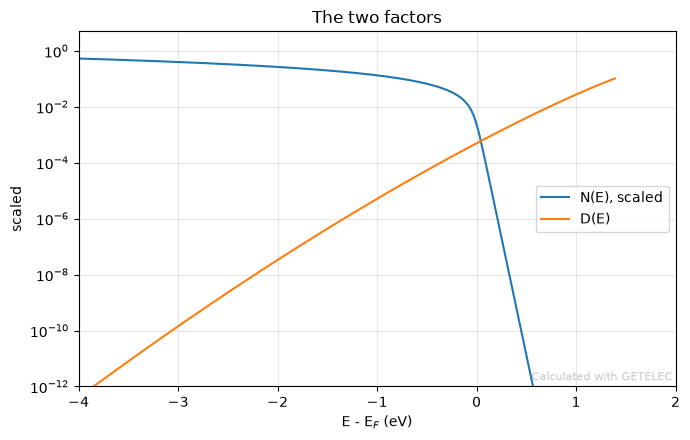

In [8]:
energies, supply = emitter.calculate_supply_function()
_, transmission = emitter.calculate_transmission_coefficient()
relative = energies - 7.5      # measure from the Fermi level

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(relative, np.maximum(supply / supply.max(), 1e-20), label="N(E), scaled")
ax.semilogy(relative, np.maximum(transmission, 1e-20), label="D(E)")
ax.set_xlim(-4, 2); ax.set_ylim(1e-12, 5)
ax.set_xlabel("E - E$_F$ (eV)"); ax.set_ylabel("scaled")
ax.set_title("The two factors"); ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

$N$ collapses above the Fermi level, where there are few electrons, while $D$
falls by orders of magnitude going down in energy as the barrier thickens. Field
emission comes from the narrow window just below $E_F$ where both are
appreciable.

### Energy distributions

`TED` is the total energy distribution — what an electron energy analyser
measures. `NED` is the normal one, in the energy of motion perpendicular to the
surface.

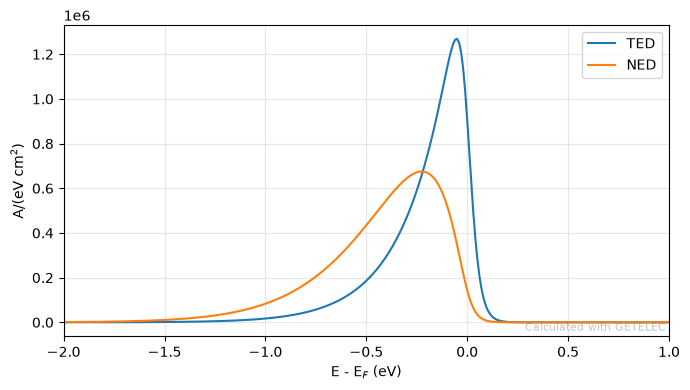

integral of TED = 4.0874e+05,  of NED = 4.0867e+05,  J = 4.0874e+05


In [9]:
e_ted, ted = emitter.calculate_total_energy_distribution()
e_ned, ned = emitter.calculate_normal_energy_distribution()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e_ted - 7.5, ted, label="TED")
ax.plot(e_ned - 7.5, ned, label="NED")
ax.set_xlim(-2, 1)
ax.set_xlabel("E - E$_F$ (eV)"); ax.set_ylabel("A/(eV cm$^2$)")
ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

print(f"integral of TED = {np.trapezoid(ted, e_ted):.4e},  "
      f"of NED = {np.trapezoid(ned, e_ned):.4e},  J = {emitter.calculate_current_density():.4e}")

## 5. Changing the emitter

`update_params` sets a parameter **everywhere it appears**. The Fermi level, for
instance, lives on the barrier *and* on the supply function; setting it in only
one place is an easy way to get quietly wrong physics. Short aliases are
accepted: `field`, `temp`, `wf`, `fermi`.

In [10]:
emitter.update_params(field=6.0, temp=800.0)
print(f"after update: J = {emitter.calculate_current_density():.4e} A/cm^2")

# A typo raises rather than being silently ignored.
try:
    emitter.update_params(workfunction=4.5)
except KeyError as error:
    print(f"typo caught: {str(error)[:70]}...")

after update: J = 4.7543e+06 A/cm^2
typo caught: "No component of this emitter has a parameter named 'workfunction' (re...


Reuse an emitter when you want several outputs from one state: it memoises
against a fingerprint of everything it depends on, so current density, then
Nottingham heat, then the distributions all come from a single solve.

In [11]:
emitter.calculate_current_density()          # warm it up
start = time.perf_counter()
for _ in range(5):
    emitter.calculate_current_density()      # same state: free
reused = (time.perf_counter() - start) / 5

start = time.perf_counter()
for _ in range(5):
    getelec.metal_emitter(field=6.0, temperature=800.0).calculate_current_density()
rebuilt = (time.perf_counter() - start) / 5
print(f"repeat on the same emitter: {reused * 1e3:.4f} ms, "
      f"a new one each time: {rebuilt * 1e3:.2f} ms")

repeat on the same emitter: 0.1889 ms, a new one each time: 3.44 ms


## 6. Choosing a solver

| how | cost | accuracy |
|---|---|---|
| `method="noumerov"` (default) | reference | exact |
| `fast=True` | ~1.5–3× cheaper | J to ~3e-5 |
| `method="ml"` | cheaper still | ~0.1% in D, ~0.3% in J (typical) |
| `method="wkb"` | cheapest | factor of order 1 |

`"noumerov"` solves the Schrödinger equation with Noumerov's method, whose local
truncation error is O(h⁶): one of the most accurate methods for this equation,
and fast, with a single three-term recurrence per grid point. `"ml"` is a
trained neural network; section 9 shows where it pays off.

In [12]:
exact = getelec.current_density(field=5.0)
for label, kw in (("fast=True", {"fast": True}), ("method='ml'", {"method": "ml"}),
                  ("method='wkb'", {"method": "wkb"})):
    value = getelec.current_density(field=5.0, **kw)
    print(f"{label:<13} {value:.6e}   ({abs(value - exact) / exact:.2e} off)")

fast=True     4.087293e+05   (2.72e-05 off)
method='ml'   4.099323e+05   (2.92e-03 off)
method='wkb'  3.793378e+05   (7.19e-02 off)


## 7. Checking the answer

`h = 1e-3` nm is a default, not a guarantee. Refine the spatial grid and see how
much the answer moves.

In [13]:
from getelec.transmission_solver import Noumerov
from getelec.potential_barrier import SchottkyPotential

barrier = SchottkyPotential(fermi_level=7.5, work_function=4.5, electric_field=5.0)
report = Noumerov(h=1e-3).calculate_convergence_report(barrier, np.arange(4.0, 9.0, 0.5))
for step, deviation in sorted(report.items(), reverse=True):
    print(f"h = {step:<9g} deviates from the finest grid by {deviation:.2e}")

h = 0.001     deviates from the finest grid by 2.59e-05
h = 0.0005    deviates from the finest grid by 6.74e-06
h = 0.00025   deviates from the finest grid by 0.00e+00


## 8. Semiconductors

Same idea, but conduction and valence bands are treated separately and every
accessor returns **both**.

J = 1.1801e+04 A/cm^2


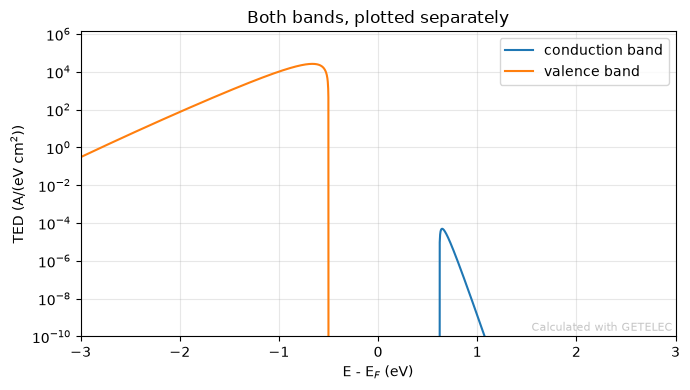

In [14]:
semiconductor = getelec.semiconductor_emitter(
    work_function=4.5, fermi_level=13.0, temperature=300.0, field=5.0,
    band_gap=1.12, top_valence=12.5,          # silicon-like
    electron_eff_mass=1.64, hole_eff_mass=0.68)

print(f"J = {semiconductor.calculate_current_density():.4e} A/cm^2")

e_cb, ted_cb, e_vb, ted_vb = semiconductor.calculate_total_energy_distribution()
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(e_cb - 13.0, np.maximum(ted_cb, 1e-30), label="conduction band")
ax.semilogy(e_vb - 13.0, np.maximum(ted_vb, 1e-30), label="valence band")
ax.set_xlim(-3, 3); ax.set_ylim(1e-10, None)
ax.set_xlabel("E - E$_F$ (eV)"); ax.set_ylabel("TED (A/(eV cm$^2$))")
ax.set_title("Both bands, plotted separately"); ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

### The normal energy distribution can sit in the band gap

With an electron effective mass above the free mass, as here ($m_e^* = 1.64$),
the conduction band's normal energy distribution reaches **below** the band
edge $E_C$, while the total energy distribution goes to zero there.

This is correct, and it does not mean there are electrons in the gap. $E_z$ is
the normal energy *in vacuum*, which is what the tunnelling depends on. The
parallel momentum is conserved at the surface, but the mass changes, so in
vacuum it can carry more transverse energy than the electron's whole kinetic
energy in the band. The tail carries real current: cutting it off at $E_C$
would lose it. `GUIDE.md`, "Semiconductors: the two energy distributions", has
the details.

share of the conduction current with E_z below E_C: 35.0%


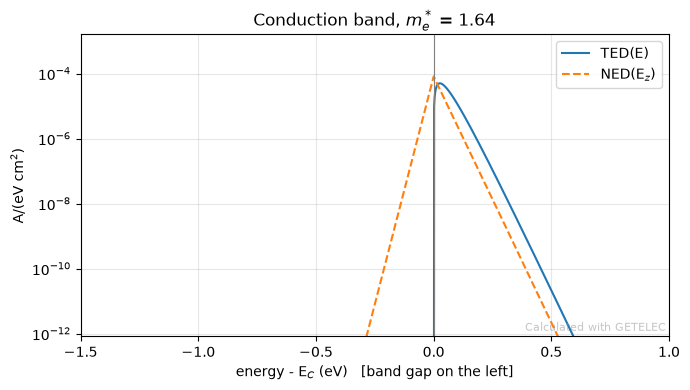

In [15]:
from scipy.integrate import cumulative_trapezoid

e_c = 12.5 + 1.12                              # top_valence + band_gap
x_cb, ned_cb, _, _ = semiconductor.calculate_normal_energy_distribution()

# Read the running integral at exactly E_C; cutting at the last grid point
# below it would drop a sliver right where the NED peaks.
running = cumulative_trapezoid(ned_cb, x_cb, initial=0.0)
share = np.interp(e_c, x_cb, running) / running[-1]
print(f"share of the conduction current with E_z below E_C: {share:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(e_cb - e_c, np.maximum(ted_cb, 1e-30), label="TED(E)")
ax.semilogy(x_cb - e_c, np.maximum(ned_cb, 1e-30), "--", label="NED(E$_z$)")
ax.axvline(0.0, color="grey", lw=0.8)
ax.set_xlim(-1.5, 1.0); ax.set_ylim(max(ted_cb.max(), ned_cb.max()) * 1e-8, None)
ax.set_xlabel("energy - E$_C$ (eV)   [band gap on the left]")
ax.set_ylabel("A/(eV cm$^2$)")
ax.set_title("Conduction band, $m_e^*$ = 1.64"); ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

### Where the effective masses actually act

Change `electron_eff_mass` and the current moves — but `D(E)` comes back
**bit-identical**. That is the model, not a bug: the barrier holds no effective
mass (neither does the published 2.0 code). The masses enter only through the
limits of the window Eq. (8) puts on the normal energy,

$$g(E)=\int_{\text{lower}(E)}^{E} D(E_z)\,\mathrm{d}E_z ,\qquad
\text{TED}(E)=f(E)\,g(E),$$

so $g$ is the smallest thing that shows the masses reaching the transmission.
`calculate_window_integrated_transmission()` returns it, and the GUI plots it
for semiconductors under **g(E) (D over the mass window)**.

The electron mass acts on the conduction band alone, so the two bands are
printed separately below: at these parameters the valence band carries all but
a billionth of the current, and the change would be invisible in the total.

Three things it is not. It is **not a probability** — it is a transmission
integrated over an energy range, so it is in eV and not bounded by 1. It is
**not the per-electron transmission**: the mean over the window, $g/\text{width}$,
*falls* with mass, because the window opens downwards towards smaller $D$; $g$
is plotted because it is what multiplies the occupancy to make the current. And
it is **not** the by-parts integrand $g'(E)=D(E)-\bar\alpha D(\text{lower}(E))$,
which is negative throughout the valence band at every hole mass and is not
returned anywhere.

D(E) identical across the two masses: True
m* = 0.50 :  conduction 1.2342e-06   valence 1.1801e+04 A/cm^2
m* = 1.64 :  conduction 3.6015e-06   valence 1.1801e+04 A/cm^2


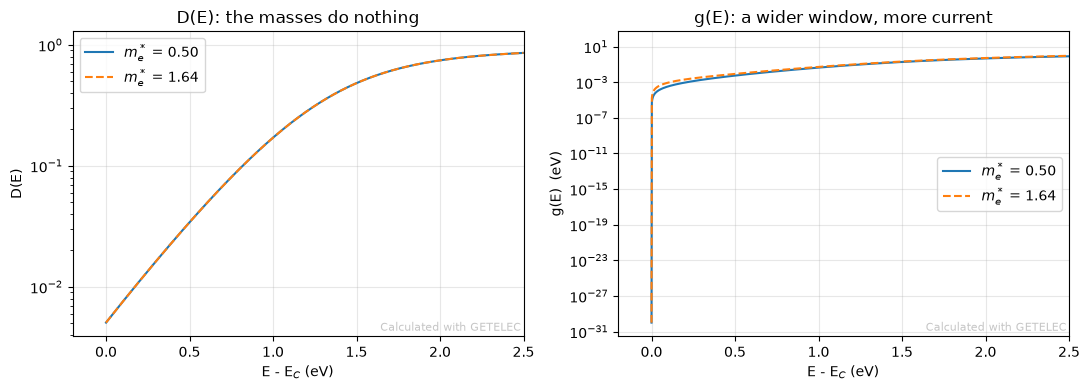

In [16]:
light = getelec.semiconductor_emitter(
    work_function=4.5, fermi_level=13.0, temperature=300.0, field=5.0,
    band_gap=1.12, top_valence=12.5, electron_eff_mass=0.5, hole_eff_mass=0.68)
heavy = getelec.semiconductor_emitter(
    work_function=4.5, fermi_level=13.0, temperature=300.0, field=5.0,
    band_gap=1.12, top_valence=12.5, electron_eff_mass=1.64, hole_eff_mass=0.68)

_, d_light, _, _ = light.calculate_transmission_coefficient()
_, d_heavy, _, _ = heavy.calculate_transmission_coefficient()
print('D(E) identical across the two masses:', np.array_equal(d_light, d_heavy))

e_light, g_light, _, _ = light.calculate_window_integrated_transmission()
e_heavy, g_heavy, _, _ = heavy.calculate_window_integrated_transmission()

# The electron mass acts on the conduction band only, and here the valence band
# carries essentially all of the current -- so compare the conduction band on
# its own, or the change is invisible in the total.
from getelec.electron_emitter import get_energy_integral

for name, emitter in (("0.50", light), ("1.64", heavy)):
    e_cb, ted_cb, e_vb, ted_vb = emitter.calculate_total_energy_distribution()
    print(f"m* = {name} :  conduction {get_energy_integral(e_cb, ted_cb):.4e}"
          f"   valence {get_energy_integral(e_vb, ted_vb):.4e} A/cm^2")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(e_light - e_c, np.maximum(d_light, 1e-30), label="$m_e^*$ = 0.50")
axes[0].semilogy(e_heavy - e_c, np.maximum(d_heavy, 1e-30), "--", label="$m_e^*$ = 1.64")
axes[0].set_ylabel("D(E)"); axes[0].set_title("D(E): the masses do nothing")
axes[1].semilogy(e_light - e_c, np.maximum(g_light, 1e-30), label="$m_e^*$ = 0.50")
axes[1].semilogy(e_heavy - e_c, np.maximum(g_heavy, 1e-30), "--", label="$m_e^*$ = 1.64")
axes[1].set_ylabel("g(E)  (eV)"); axes[1].set_title("g(E): a wider window, more current")
for ax in axes:
    ax.set_xlim(-0.2, 2.5); ax.set_xlabel("E - E$_C$ (eV)")
    ax.legend(); ax.grid(alpha=0.3)
    getelec.watermark(ax)
plt.tight_layout(); plt.show()

## 9. Sharp tips and the neural solver

`barrier="sharp_tip"` adds the curvature of a tip of radius $R$ (nm; valid for
20–1000 nm) with field enhancement $\gamma$. Two more parameters: a sweep of
exact solves grows with each one, and a table would grow with each one too. A
trained network does not, which is why `method="ml"` exists.

It picks the model trained for the barrier's class, and outside that model's
training range it hands the calculation to the exact solver rather than
extrapolating. The shipped sharp-tip model covers the whole valid range,
$R$ = 20–1000 nm and $\gamma$ = 1–200. For the plain planar barrier a model
ships too, but only as a worked example: that calculation was never slow.

R =   20 nm:  J / J_planar = 0.566
R =  100 nm:  J / J_planar = 0.895
R = 1000 nm:  J / J_planar = 0.989
R = 50 nm, worst difference over the field sweep: 0.24%;   exact 0.03 s, network 0.04 s


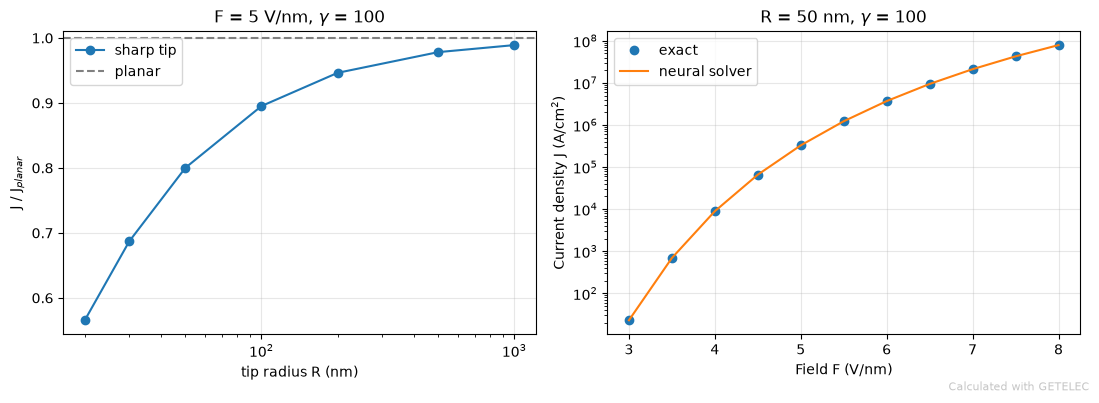

In [17]:
radii = np.array([20.0, 30.0, 50.0, 100.0, 200.0, 500.0, 1000.0])
planar = getelec.current_density(field=5.0)
tip = np.array([getelec.current_density(field=5.0, barrier="sharp_tip", radius=r,
                                        gamma=100.0) for r in radii])
for r in (20.0, 100.0, 1000.0):
    print(f"R = {r:4.0f} nm:  J / J_planar = {tip[np.isclose(radii, r)][0] / planar:.3f}")

# The shipped network: a field sweep at R = 50 nm.
fields = np.linspace(3.0, 8.0, 11)


def field_sweep(**kw):
    start = time.perf_counter()
    values = getelec.current_density(field=fields, barrier="sharp_tip", radius=50.0,
                                     gamma=100.0, **kw)
    return values, time.perf_counter() - start


exact_tip, t_exact = field_sweep()
learned_tip, t_learned = field_sweep(method="ml")
print(f"R = 50 nm, worst difference over the field sweep: "
      f"{np.max(np.abs(learned_tip / exact_tip - 1)):.2%};   "
      f"exact {t_exact:.2f} s, network {t_learned:.2f} s")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(radii, tip / planar, "o-", label="sharp tip")
ax[0].axhline(1.0, color="grey", ls="--", label="planar")
ax[0].set_xlabel("tip radius R (nm)"); ax[0].set_ylabel("J / J$_{planar}$")
ax[0].set_title("F = 5 V/nm, $\\gamma$ = 100")
ax[1].semilogy(fields, exact_tip, "o", label="exact")
ax[1].semilogy(fields, learned_tip, "-", label="neural solver")
ax[1].set_xlabel("Field F (V/nm)"); ax[1].set_ylabel("Current density J (A/cm$^2$)")
ax[1].set_title("R = 50 nm, $\\gamma$ = 100")
for a in ax:
    a.legend(); a.grid(alpha=0.3)
getelec.watermark(fig)
plt.tight_layout(); plt.show()

At fixed apex field a sharp tip emits *less* than a planar surface: away from
the apex the field falls off, so the barrier is wider. Across the valid range
the potential stays within a few percent of the work function of the planar
Schottky–Nordheim barrier, but the current, which depends on the barrier
exponentially, does not: at 20 nm and 5 V/nm it is little more than half the
planar value, and it reaches the planar value only towards 1000 nm, the top of
the range. Below 20 nm the current also depends on the shape of the tip beyond
its apex, which the barrier does not describe; `GUIDE.md` gives the size of that
difference.

**Your own barrier.** The shipped models cover one training range each. For your
own conditions — another range, another barrier — train a model with
`getelec.training` (needs `pip install scikit-learn`; using one needs only
NumPy). `python -m getelec.training` reproduces the shipped Schottky model and
`python -m getelec.training --barrier small_radii` the sharp-tip one; the module
docstring is the recipe for a new barrier. `GUIDE.md` explains why the network
learns a small correction to a semiclassical reference rather than the
transmission itself.

## 10. The wavefunction

If you need $\psi$ itself — a charge density, a probability current, the decay
through the barrier — ask the emitter. This needs the full `Noumerov` solver,
which is the default; the fast preset and the neural solver never form $\psi$
and will tell you so rather than substituting something else. The array is 16
bytes per (energy, grid point), so **pass `energies=`**.

One thing to set explicitly here: the default integration domain starts at
`x_metal = -0.01` nm, because a transmission coefficient is matched at the last
two grid points and needs no more metal than that. A picture of $\psi$ does —
the incident and reflected waves interfere into a standing wave whose period is
$\pi/k \approx 0.3$ nm, so a domain one hundredth of that shows nothing. Asking
for `x_metal=-1.0` costs a little time and buys three or four visible periods.

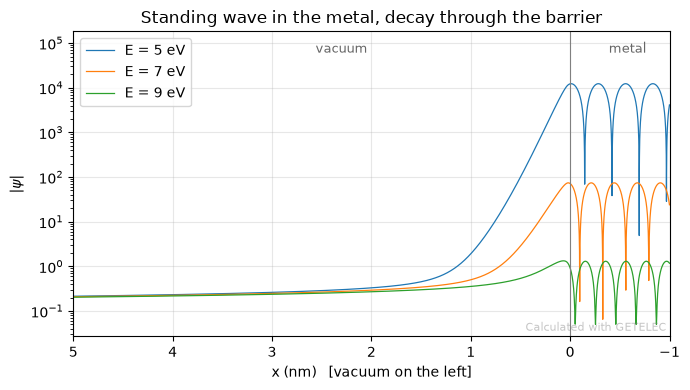

E = 7 eV: current varies by 2.05e-09 across the metal
E = 8 eV: current varies by 2.62e-11 across the metal


In [18]:
# A wider domain than the default, for the picture rather than for the physics:
# 1 nm of metal to show the standing wave, 4 nm past the barrier for the tail.
psi_emitter = getelec.metal_emitter(field=5.0, x_metal=-1.0, x_vac_plus=4.0)
x_points = np.linspace(-1.0, 5.0, 6001)      # snapped to the solver's own nodes
energies, x, psi = psi_emitter.calculate_psi(energies=[5.0, 7.0, 9.0],
                                             x_points=x_points)

fig, ax = plt.subplots(figsize=(7, 4))
for row, energy in zip(psi, energies):
    ax.semilogy(x, np.abs(row), lw=0.9, label=f"E = {energy:.0f} eV")
ax.axvline(0.0, color="0.5", lw=0.8)                 # the surface
ax.set_xlim(5, -1); ax.set_xlabel("x (nm)   [vacuum on the left]")
# Headroom for the region labels, which go in axes fractions so that they
# follow the limits rather than the data (and clear the watermark below).
ax.set_ylim(top=ax.get_ylim()[1] * 8)
ax.text(0.45, 0.93, "vacuum", transform=ax.transAxes,
        ha="center", color="0.4", fontsize=9)
ax.text(0.93, 0.93, "metal", transform=ax.transAxes,
        ha="center", color="0.4", fontsize=9)
ax.set_ylabel(r"$|\psi|$")
ax.set_title("Standing wave in the metal, decay through the barrier")
ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

# The probability current must be the same everywhere in a stationary state;
# the solver does not enforce it, so its variation is an honest check. The
# wider metal side above is what makes this a real test: it is measured over
# half a nanometre, several periods of the standing wave, not over a few nodes.
energies, x, current = psi_emitter.calculate_probability_current(energies=[7.0, 8.0])
inside = (x > -0.5) & (x < 0.0)
for row, energy in zip(current, energies):
    values = row[inside]
    print(f"E = {energy:.0f} eV: current varies by "
          f"{(values.max() - values.min()) / abs(values.mean()):.2e} across the metal")

## 11. Full control

The convenience functions just assemble the four components. Build them
yourself for anything the shortcuts do not expose.

In [19]:
from getelec.band_structure import SmartMetal
from getelec.electron_supply import LogFermiDirac
from getelec.electron_emitter import MetalEmitter

custom = MetalEmitter(
    SchottkyPotential(fermi_level=7.5, work_function=4.5, electric_field=5.0),
    Noumerov(h=5e-4),                       # finer spatial grid
    LogFermiDirac(fermi_level=7.5, temperature=300.0),
    SmartMetal(energy_resolution=0.005),    # finer energy grid
)
print(f"J = {custom.calculate_current_density():.6e} A/cm^2")
print(f"default settings: {getelec.current_density(field=5.0):.6e} A/cm^2")

J = 4.086862e+05 A/cm^2
default settings: 4.087404e+05 A/cm^2


## 12. Fitting experimental data

### An I–V curve

`iv.txt`: a tungsten (111) tip at room temperature, voltage (V) against current
(nA). The model is $I = A\,J(F = \gamma V)$, with $\gamma$ the field per volt
and $A$ the emission area. Two choices matter:

- **Fit in log current.** The data spans decades; a fit on raw values would be
  dominated entirely by the highest-voltage points.
- **Assume the work function** (4.5 eV here). The cell after the plot frees it,
  to show what a single I–V curve can say about it.

gamma = 0.00398 V/nm per V,  area = 2.50e-13 cm^2,  scatter 0.069 in ln I


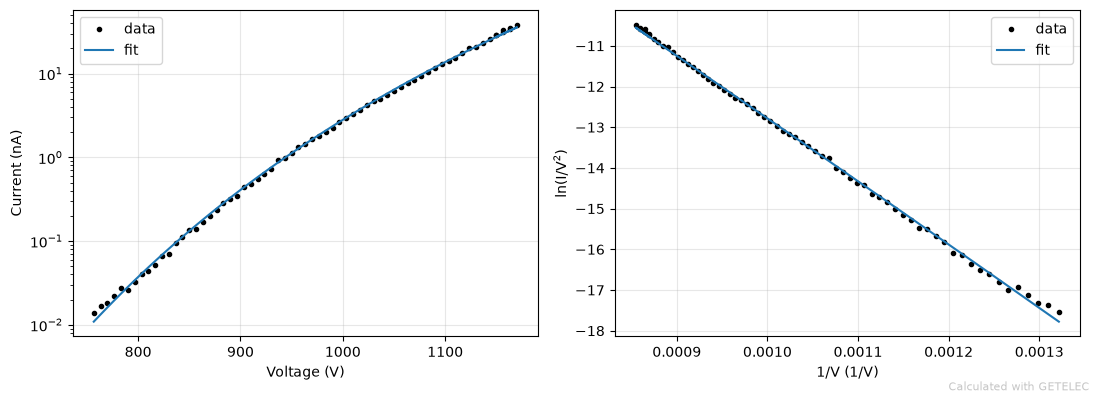

In [20]:
from pathlib import Path
from scipy.optimize import curve_fit

# iv.txt and ted.txt sit next to this notebook, in examples/. Jupyter normally
# runs a notebook from its own folder, but depending on the editor's settings it
# may run from the project folder instead, so look in both.
DATA = next((folder for folder in (Path.cwd(), Path.cwd() / "examples")
             if (folder / "iv.txt").is_file()), None)
if DATA is None:
    raise FileNotFoundError(
        f"iv.txt not found in {Path.cwd()} or its examples folder. The data files "
        "are in the examples folder of the GETELEC repository; put them next to "
        "this notebook.")

voltage, current = np.loadtxt(DATA / "iv.txt", unpack=True)
keep = current > 0
voltage, current = voltage[keep], current[keep]


def log_current(v, gamma, area, work_function=4.5, fermi_level=7.5, temperature=300.0):
    j = getelec.current_density(field=v * gamma, work_function=work_function,
                                fermi_level=fermi_level, temperature=temperature,
                                fast=True)
    return np.log(np.clip(j * area * 1e9, 1e-300, None))      # current in nA


# The area spans decades, so it is fitted in its logarithm.
(gamma_fit, log_area), _ = curve_fit(lambda v, g, la: log_current(v, g, 10.0 ** la),
                                     voltage, np.log(current), p0=[0.0045, -11.0])
area_fit = 10.0 ** log_area
residual = np.log(current) - log_current(voltage, gamma_fit, area_fit)
print(f"gamma = {gamma_fit:.5f} V/nm per V,  area = {area_fit:.2e} cm^2,  "
      f"scatter {residual.std():.3f} in ln I")

model_current = np.exp(log_current(voltage, gamma_fit, area_fit))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(voltage, current, "ko", ms=3, label="data")
ax[0].semilogy(voltage, model_current, label="fit")
ax[0].set_xlabel("Voltage (V)"); ax[0].set_ylabel("Current (nA)")
ax[1].plot(1 / voltage, np.log(current / voltage**2), "ko", ms=3, label="data")
ax[1].plot(1 / voltage, np.log(model_current / voltage**2), label="fit")
ax[1].set_xlabel("1/V (1/V)"); ax[1].set_ylabel("ln(I/V$^2$)")
for a in ax:
    a.legend(); a.grid(alpha=0.3)
getelec.watermark(fig)
plt.tight_layout(); plt.show()

### The same I–V fit, with the work function free

Now $\phi$ is a third fit parameter. The fit runs twice, from two starting
guesses. Each prints the parameters with the standard errors `curve_fit`
reports (the square root of the covariance diagonal), the scatter of the fit,
and the correlation between $\gamma$ and $\phi$.

In [21]:
labels = ["gamma (V/nm per V)", "log10 area (cm^2)", "work function (eV)"]
for phi_start in (4.0, 5.5):
    popt, pcov = curve_fit(
        lambda v, g, la, phi: log_current(v, g, 10.0 ** la, work_function=phi),
        voltage, np.log(current), p0=[gamma_fit, log_area, phi_start],
        bounds=([1e-4, -20.0, 2.0], [0.1, 0.0, 8.0]), x_scale=[1e-3, 1.0, 0.5])
    perr = np.sqrt(np.diag(pcov))
    scatter = (np.log(current)
               - log_current(voltage, popt[0], 10.0 ** popt[1], popt[2])).std()
    print(f"started at phi = {phi_start} eV:  scatter {scatter:.4f} in ln I")
    for name, value, error in zip(labels, popt, perr):
        print(f"    {name:20s} {value:9.4f} ± {error:.4f}")
    print(f"    correlation gamma-phi {pcov[0, 2] / (perr[0] * perr[2]):+.3f}")

started at phi = 4.0 eV:  scatter 0.0679 in ln I
    gamma (V/nm per V)      0.0096 ± 0.0578
    log10 area (cm^2)     -12.8418 ± 1.6917
    work function (eV)      8.0000 ± 31.7027
    correlation gamma-phi +1.000


started at phi = 5.5 eV:  scatter 0.0679 in ln I
    gamma (V/nm per V)      0.0096 ± 0.0577
    log10 area (cm^2)     -12.8418 ± 1.6898
    work function (eV)      8.0000 ± 31.6668
    correlation gamma-phi +1.000


Both fits describe the data equally well, yet their work functions differ by
more than 1 eV, five times the error bar of the first. The correlation between
$\gamma$ and $\phi$
is essentially 1: the curve fixes a combination of the two, and the fit slides
along it until the optimiser stops. A `±` from a fit is only an uncertainty when
the correlations are small; section 13 shows how to check.

### A total energy distribution

`ted.txt`: energies relative to the Fermi level, and counts. The fit takes the
field, the temperature and a small energy offset of the analyser, with the work
function assumed; the cell after the plot frees it. The Fermi level only sets
the zero of the energy axis. Both the data and the model are normalised to their
peak.

The model is GETELEC's full TED, built from the transmission at every energy.
The classic alternative is Young's formula,
$J(E) \propto \exp(E/d) \,/\, \big(1 + \exp[(E-\mu)/kT]\big)$, with a constant
transverse energy $d = \hbar q F / \big(2\sqrt{2m\phi}\,t(y)\big)$. With a full
transmission the low-energy slope, and so the apparent $d$, changes with energy:
a $d$ read off a fit depends on the energy range used by more than 10%, and a
work function derived from it by more than 0.5 eV. See S. Barranco Cárceles
*et al.*, "Does a field emitter have a transverse energy?", IVNC 2026,
doi:10.1109/IVNC69421.2026.11660967.

F = 5.38 ± 0.03 V/nm,  T = 358 ± 3 K,  offset = +53.6 meV


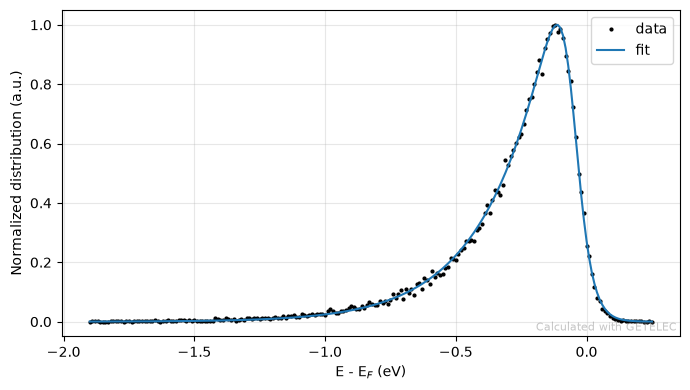

In [22]:
from getelec.band_structure import CustomMetal
from getelec.electron_supply import FermiDirac

energy, counts = np.loadtxt(DATA / "ted.txt", unpack=True)
measured = counts / counts.max()
fermi = 7.5
ted_emitter = MetalEmitter(SchottkyPotential(fermi, 4.5, 5.0), Noumerov(),
                           FermiDirac(fermi, 300.0), CustomMetal(energy + fermi))


def ted_model(e, field, temperature, offset, work_function=4.5):
    ted_emitter.band = CustomMetal(e + fermi + offset)
    ted_emitter.update_params(field=field, temp=temperature, wf=work_function)
    _, ted = ted_emitter.calculate_total_energy_distribution()
    return ted / ted.max()


(field_fit, temperature_fit, offset_fit), covariance = curve_fit(
    ted_model, energy, measured, p0=[4.0, 300.0, 0.0],
    bounds=([1.0, 50.0, -0.2], [12.0, 2000.0, 0.2]), x_scale=[0.5, 50.0, 0.01])
errors = np.sqrt(np.diag(covariance))
print(f"F = {field_fit:.2f} ± {errors[0]:.2f} V/nm,  T = {temperature_fit:.0f} ± "
      f"{errors[1]:.0f} K,  offset = {offset_fit * 1e3:+.1f} meV")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(energy, measured, "ko", ms=2, label="data")
ax.plot(energy, ted_model(energy, field_fit, temperature_fit, offset_fit), label="fit")
ax.set_xlabel("E - E$_F$ (eV)"); ax.set_ylabel("Normalized distribution (a.u.)")
ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

### The same TED fit, with the work function free

In [23]:
bounds = ([1.0, 50.0, -0.2, 2.0], [12.0, 2000.0, 0.2, 8.0])
popt, pcov = curve_fit(ted_model, energy, measured,
                       p0=[field_fit, temperature_fit, offset_fit, 4.5],
                       bounds=bounds, x_scale=[0.5, 50.0, 0.01, 0.5])
perr = np.sqrt(np.diag(pcov))
labels = ["F (V/nm)", "T (K)", "offset (eV)", "work function (eV)"]
for name, value, error, low, high in zip(labels, popt, perr, *bounds):
    at_bound = "   <- at its bound" if np.isclose(value, low) or np.isclose(value, high) else ""
    print(f"    {name:20s} {value:9.4f} ± {error:.4f}{at_bound}")
print(f"correlation F-phi {pcov[0, 3] / (perr[0] * perr[3]):+.3f}")
rms_assumed = (measured - ted_model(energy, field_fit, temperature_fit, offset_fit)).std()
rms_free = (measured - ted_model(energy, *popt)).std()
print(f"rms misfit: {rms_assumed:.4f} with phi assumed, {rms_free:.4f} with phi free")
print(f"F/sqrt(phi): {field_fit / np.sqrt(4.5):.3f} with phi assumed, "
      f"{popt[0] / np.sqrt(popt[3]):.3f} with phi free")

    F (V/nm)                7.0679 ± 3.0010
    T (K)                 359.6448 ± 3.8739
    offset (eV)             0.0541 ± 0.0008
    work function (eV)      8.0000 ± 7.0646   <- at its bound
correlation F-phi +1.000
rms misfit: 0.0104 with phi assumed, 0.0103 with phi free
F/sqrt(phi): 2.534 with phi assumed, 2.499 with phi free


The work function runs to the edge of the range it is allowed, and the field
follows it. In Young's picture the low-energy side falls off as $\exp(E/d)$ with
$d \propto F/\sqrt{\phi}$ (up to the slowly varying $t$), so the shape fixes
roughly that ratio rather than $F$ and $\phi$ separately: the two printed ratios
are close while $F$ itself has moved a long way. Even the ratio is only loosely
defined, because the apparent $d$ varies with energy (Barranco Cárceles
*et al.*, IVNC 2026, cited above). The `±` values here mean nothing; a
covariance evaluated at a bound is not an uncertainty.

## 13. What a fit can and cannot tell you

A fit converging says nothing about whether the data constrains what was fitted.
Field-emission fits routinely report five numbers — field factor, area, Fermi
level, work function, temperature — from one I–V curve. Here is how much of
that the curve above actually determines.

The **Fisher information** $F = J^T J / \sigma^2$, with $J$ the sensitivity of
$\ln I$ to each parameter (in relative units) and $\sigma$ the scatter, has
eigenvectors that are the parameter *combinations* the data speaks about, and
eigenvalues that say how loudly. (Ayari *et al.*, J. Vac. Sci. Technol. B **41**,
024001 (2023), asks the question.)

condition number: 8.6e+10
  relative to the stiffest  1.0e+00   -0.83*work function +0.56*gamma
  relative to the stiffest  2.2e-05   +0.81*area -0.43*Fermi level
  relative to the stiffest  3.0e-09   +0.72*temperature +0.53*gamma
  relative to the stiffest  3.7e-11   +0.82*Fermi level +0.49*area
  relative to the stiffest  1.2e-11   +0.63*temperature -0.55*gamma


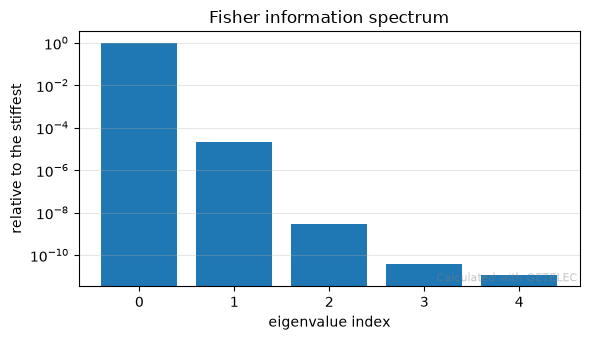

In [24]:
names = ["gamma", "area", "work function", "Fermi level", "temperature"]
best = np.array([gamma_fit, area_fit, 4.5, 7.5, 300.0])
sensitivity = np.empty((voltage.size, best.size))
for k in range(best.size):
    step = 1e-3 * best[k]
    up, down = best.copy(), best.copy()
    up[k] += step
    down[k] -= step
    sensitivity[:, k] = (log_current(voltage, *up) - log_current(voltage, *down)) \
        / (2 * step) * best[k]

fisher = sensitivity.T @ sensitivity / residual.std() ** 2
values, vectors = np.linalg.eigh(fisher)
order = np.argsort(values)[::-1]
values, vectors = values[order], vectors[:, order]
print(f"condition number: {values[0] / values[-1]:.1e}")
for value, vector in zip(values, vectors.T):
    main = np.argsort(np.abs(vector))[::-1][:2]
    combo = " ".join(f"{vector[k]:+.2f}*{names[k]}" for k in main)
    print(f"  relative to the stiffest {value / values[0]:8.1e}   {combo}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(values.size), values / values[0], log=True)
ax.set_xlabel("eigenvalue index"); ax.set_ylabel("relative to the stiffest")
ax.set_title("Fisher information spectrum"); ax.grid(alpha=0.3, axis="y")
getelec.watermark(ax)
plt.tight_layout(); plt.show()

One combination is pinned down; the next is already orders of magnitude
weaker, and the rest are essentially free. A single I–V curve determines about
one and a half of the five parameters people report — which is why section 12
assumed the work function, and why freeing it there let it wander.
Per-parameter error bars from such a fit are meaningless along the sloppy
directions, however small they look.

The definitive check is **profile likelihood**: fix one parameter away from its
optimum, re-fit everything else, and watch how little the misfit rises. It takes
a re-fit per point, so it is left out here.

## 14. A tabulated density of states

Everything so far has assumed a free electron gas: a density of states going as
$\sqrt{E}$ above the bottom of the conduction band. Real metals are not that,
and `DensityOfStatesMetal` takes $g(E)$ from a table — a DFT calculation, say —
and weights each total energy by how many states it actually holds relative to
the free electron reference,

$$R(E) = \frac{g(E)/\sqrt{E}}{g(E_F)/\sqrt{E_F}} ,$$

normalised so that $R(E_F) = 1$. The current density is then comparable to the
free electron one, and $R$ acts as a shape correction rather than an unknown
overall scale — which matters, because a projected density of states has no
absolute normalisation of its own.

`dos.txt` ships next to this notebook: two columns, energy in eV measured from
the bottom of the conduction band, and the density of states. Negative energies
lie below the band bottom and are dropped on loading; what is left sets both the
range and the resolution of the emitter's energy grid.

grid: 1356 points, 0.009 to 13.559 eV, step 0.010 eV
R(E_F) = 1.000000


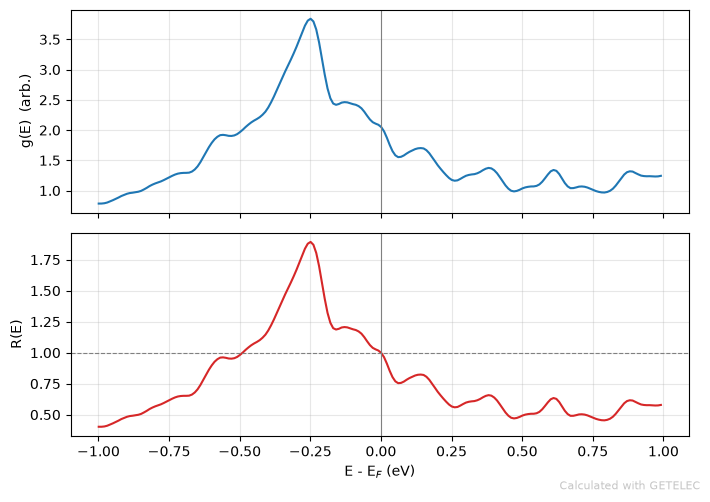

In [25]:
from getelec.band_structure import DensityOfStatesMetal

DOS = next((folder for folder in (Path.cwd(), Path.cwd() / "examples")
            if (folder / "dos.txt").is_file()), None)
if DOS is None:
    raise FileNotFoundError("dos.txt not found; it is in the examples folder.")

FERMI, WORK = 10.268, 4.67
band = DensityOfStatesMetal.from_file(DOS / "dos.txt", fermi_level=FERMI,
                                      work_function=WORK)

energies = band.generate_band_structure(electric_field=5.0, temperature=300.0)
weights = band.get_state_weights(energies)
print(f"grid: {energies.size} points, {energies[0]:.3f} to {energies[-1]:.3f} eV, "
      f"step {band.energy_resolution:.3f} eV")
print(f"R(E_F) = {float(band.get_state_weights(np.array([FERMI]))[0]):.6f}")

near = abs(energies - FERMI) < 1.0
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
top.plot(band.dos_energies[near] - FERMI, band.dos_values[near], color="tab:blue")
top.set_ylabel("g(E)  (arb.)")
bottom.plot(energies[near] - FERMI, weights[near], color="tab:red")
bottom.axhline(1.0, color="gray", lw=0.8, ls="--")
bottom.set_ylabel("R(E)"); bottom.set_xlabel("E - E$_F$ (eV)")
for panel in (top, bottom):
    panel.axvline(0.0, color="gray", lw=0.8)
    panel.grid(alpha=0.3)
getelec.watermark(fig)
plt.tight_layout(); plt.show()

The weight swings by a factor of four within half an electronvolt of $E_F$, and
the peak sits just *below* the Fermi level — squarely inside the window field
emission draws from. So it changes the distribution's shape, not just its
normalisation.

Pass the band structure to `metal_emitter` (or to `current_density`) and
everything downstream follows: the total energy distribution is weighted by $R$,
and the normal one is rebuilt from the same double integral, so both still
integrate to the current density.

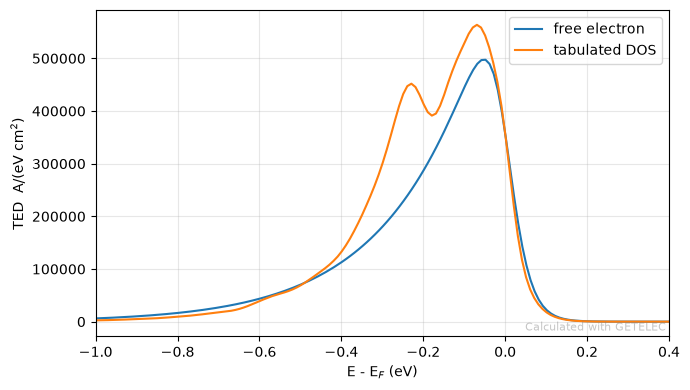

 F (V/nm)        J free   J tabulated   ratio      P_N free  P_N tabulated
      3.0    9.6122e+00    1.1254e+01   1.171   -1.0805e+00    -1.4399e+00
      5.0    1.5823e+05    1.8973e+05   1.199   -3.1957e+04    -3.7231e+04
      7.0    1.1487e+07    1.3403e+07   1.167   -3.2920e+06    -3.3417e+06

integral of TED = 1.340265e+07,  of NED = 1.340265e+07,  J = 1.340265e+07


In [26]:
free = getelec.metal_emitter(work_function=WORK, fermi_level=FERMI, field=5.0)
dosed = getelec.metal_emitter(work_function=WORK, fermi_level=FERMI, field=5.0,
                              band=band)

e_free, ted_free = free.calculate_total_energy_distribution()
e_dos, ted_dos = dosed.calculate_total_energy_distribution()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e_free - FERMI, ted_free, label="free electron")
ax.plot(e_dos - FERMI, ted_dos, label="tabulated DOS")
ax.set_xlim(-1.0, 0.4)
ax.set_xlabel("E - E$_F$ (eV)"); ax.set_ylabel("TED  A/(eV cm$^2$)")
ax.legend(); ax.grid(alpha=0.3)
getelec.watermark(ax)
plt.tight_layout(); plt.show()

print(f"{'F (V/nm)':>9} {'J free':>13} {'J tabulated':>13} {'ratio':>7}"
      f" {'P_N free':>13} {'P_N tabulated':>14}")
for field in (3.0, 5.0, 7.0):
    free.update_params(field=field)
    dosed.update_params(field=field)
    j0, j1 = free.calculate_current_density(), dosed.calculate_current_density()
    p0, p1 = free.calculate_nottingham_heat(), dosed.calculate_nottingham_heat()
    print(f"{field:9.1f} {j0:13.4e} {j1:13.4e} {j1 / j0:7.3f} {p0:13.4e} {p1:14.4e}")

e_ned, ned = dosed.calculate_normal_energy_distribution()
e_ted, ted = dosed.calculate_total_energy_distribution()
print(f"\nintegral of TED = {np.trapezoid(ted, e_ted):.6e},  "
      f"of NED = {np.trapezoid(ned, e_ned):.6e},  "
      f"J = {dosed.calculate_current_density():.6e}")

### What this is, and what it is not

Two limits are worth stating plainly.

**The density of states is a proxy for the right quantity, not the right
quantity.** In the supply integral the group velocity cancels the Jacobian,
$v_z\,\mathrm{d}k_z = \mathrm{d}E/\hbar$, so what belongs here is the number of
forward-propagating channels at energy $E$ — the constant-energy surface
projected on the surface plane — while the density of states weights states by
one over that same velocity. Writing $R = g/\sqrt{E}$ assumes the two are
related as they are for free electrons. Flat bands carry a large $g$ but a small
projected area, so their contribution is overestimated. Treat this as a model of
how the band structure influences emission rather than a first-principles
calculation of it.

**A table ends where its calculation ran out of bands.** The density of states
falls to zero at the top edge of the table for that reason, not a physical one.
Field emission never notices — at 300 K the share of the current coming from the
table's top electronvolt is around $10^{-30}$ at every field above. Thermionic
emission is another matter: it draws from the top of the barrier, which sits
close to the end of the table, and at 1.5 V/nm and 2000 K that share reaches
0.99. The emitter warns when the grid clears the barrier top by less than
$8\,k_BT$; the cell below shows both cases.

In [27]:
import warnings

for field, temperature in ((5.0, 300.0), (1.5, 2000.0)):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        band.generate_band_structure(electric_field=field, temperature=temperature)
    note = str(caught[0].message).split(".")[0] if caught else "no warning"
    print(f"{field:4.1f} V/nm, {temperature:6.0f} K: {note}")

 5.0 V/nm,    300 K: no warning
 1.5 V/nm,   2000 K: The tabulated density of states ends at 13


## 15. Your own barrier

The shipped barriers are formulas. `potential_barrier.Customised` takes a
potential of your own instead — a formula, or a profile computed elsewhere (a
self-consistent or DFT surface potential, a field solver's output) — and hands
it to the same solvers, emitters and distributions.

The conventions are those of the shipped barriers: $x$ in nm, $V$ in eV,
measured from the bottom of the conduction band, so $V = 0$ inside the metal
(held there for you) and $E_F + \phi$ at the surface before the field and the
image charge pull it down. A function takes an array of positions and returns
an array of the same shape.

Its parameters named `fermi_level`, `work_function`, `electric_field` and
`temperature` are filled in by the emitter — `metal_emitter`, `update_params`
and the sweeps of `current_density` set them, as on every other component — so
a field sweep moves your barrier too. Any other named parameter is given to
`Customised` and passed at every call. Below, `image_strength` scales the image
charge term: 0 is the triangular barrier and 1 the Schottky–Nordheim one. Both
ends must reproduce the shipped barriers, and checking a limit like that is the
first thing to do with any barrier of your own.

image_strength = 0.0: J = 3.480778e+03 A/cm^2, barrier='triangular': 3.480778e+03 A/cm^2
image_strength = 1.0: J = 4.087404e+05 A/cm^2, barrier='schottky': 4.087404e+05 A/cm^2


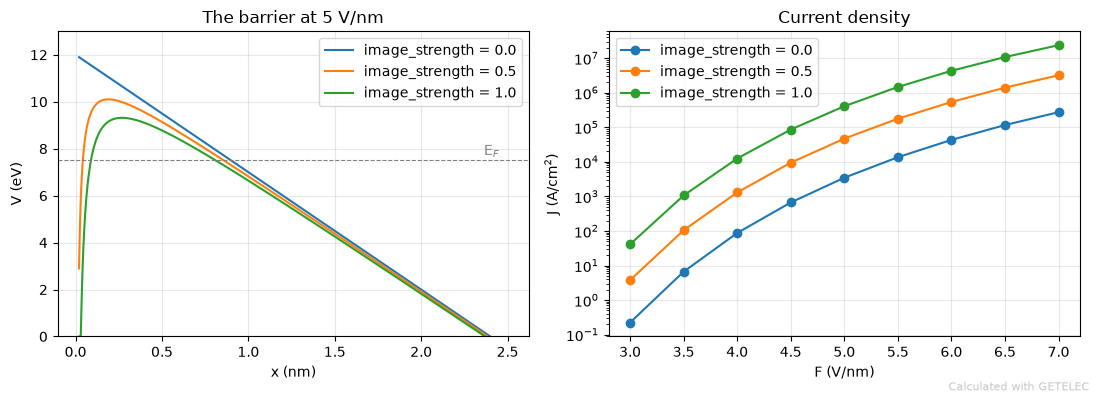

In [28]:
from getelec import constants
from getelec.potential_barrier import Customised

def image_scaled(x, fermi_level, work_function, electric_field, image_strength):
    # Schottky-Nordheim barrier with its image term scaled; nm in, eV out.
    W = fermi_level + work_function
    V = W - electric_field * x - image_strength * constants.COULOMB_CONST / (4 * x)
    # The image term diverges at the surface. Cut it off where the potential
    # first crosses zero, as the shipped barriers do.
    inner_root = (W - np.sqrt(W**2 - image_strength * constants.COULOMB_CONST
                              * electric_field)) / (2 * electric_field)
    V[x < inner_root] = 0.0
    return V

for strength, shipped in ((0.0, "triangular"), (1.0, "schottky")):
    mine = getelec.current_density(field=5.0,
                                   barrier=Customised(image_scaled, image_strength=strength))
    theirs = getelec.current_density(field=5.0, barrier=shipped)
    print(f"image_strength = {strength}: J = {mine:.6e} A/cm^2, "
          f"barrier='{shipped}': {theirs:.6e} A/cm^2")

x = np.linspace(0.02, 2.5, 500)
fields = np.linspace(3.0, 7.0, 9)
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for strength in (0.0, 0.5, 1.0):
    left.plot(x, image_scaled(x, 7.5, 4.5, 5.0, strength),
              label=f"image_strength = {strength}")
    right.semilogy(fields, getelec.current_density(
        field=fields, barrier=Customised(image_scaled, image_strength=strength)),
        "o-", label=f"image_strength = {strength}")
left.axhline(7.5, color="gray", lw=0.8, ls="--")
left.text(2.45, 7.7, "E$_F$", ha="right", color="gray")
left.set_ylim(0, 13)
left.set_xlabel("x (nm)"); left.set_ylabel("V (eV)")
left.set_title("The barrier at 5 V/nm")
right.set_xlabel("F (V/nm)"); right.set_ylabel("J (A/cm$^2$)")
right.set_title("Current density")
for panel in (left, right):
    panel.legend(); panel.grid(alpha=0.3)
getelec.watermark(fig)
plt.tight_layout(); plt.show()

The image charge lowers and rounds the top of the barrier, and at 5 V/nm that is
worth two orders of magnitude in current.

**A table** is `Customised(values, positions)`, interpolated linearly. It is one
potential, computed at one field, so it does not follow a sweep. It has to reach
as far as the solver's integration domain, several nanometres and longer at low
field; past its ends the end values are held, and the emitter warns and names
the range it needed. Linear interpolation converges slowly where the potential
bends sharply, which is near the surface. Here the Schottky–Nordheim barrier is
tabulated as if it came from another code, at decreasing steps:

In [29]:
schottky = SchottkyPotential(fermi_level=7.5, work_function=4.5, electric_field=5.0)
formula = getelec.current_density(field=5.0)
for step in (0.1, 0.05, 0.02, 0.01):
    positions = np.arange(0.0, 8.0 + step, step)
    table = Customised(schottky.get_potential(positions), positions)
    tabulated = getelec.current_density(field=5.0, barrier=table)
    print(f"table every {step:4.2f} nm: J = {tabulated:.4e} A/cm^2, "
          f"{tabulated / formula - 1:+.1e} from the formula")

table every 0.10 nm: J = 4.8035e+05 A/cm^2, +1.8e-01 from the formula
table every 0.05 nm: J = 4.2793e+05 A/cm^2, +4.7e-02 from the formula
table every 0.02 nm: J = 4.1184e+05 A/cm^2, +7.6e-03 from the formula
table every 0.01 nm: J = 4.1042e+05 A/cm^2, +4.1e-03 from the formula


Halve the step until the current stops moving; here 0.02 nm is needed for 1%.

Two limits. Only the solvers that integrate on a grid read your potential: the
default Noumerov, `fast=True` and `reference=True`. `method="wkb"` and
`method="airy"` work from $E_F$, $\phi$ and $F$ alone, so they return the
Schottky–Nordheim and triangular answers, not yours, and `method="ml"` has no
trained model for it and falls back to the exact solver. And
`semiconductor_emitter` sets none of the four parameters on a barrier it is
given: pass them to `Customised` yourself.

## Common mistakes

1. **Field in V/m.** It is V/nm. 5, not 5e9.
2. **Setting `fermi_level` on one component only.** Use `update_params`.
3. **Reading the conduction NED below $E_C$ as electrons in the gap.** It is
   a normal energy in vacuum, not the energy of a state. See section 8.
4. **A log axis on data that can be negative.** The Nottingham heat changes
   sign.
5. **Expecting `calculate_psi` from a fast or neural solver.** They never
   form ψ; use the default `Noumerov`.
6. **Trusting a fit's error bars.** See section 13.

## Where next

- `GUIDE.md` — the physics and how the code is organised.
- `docs/getelec.html` — the API reference.
- `python gui.py` — all of this, with buttons.

## Citing GETELEC

If you use GETELEC, please cite the software,

- S. Barranco Cárceles, A. Kyritsakis and A. Ayari, *GETELEC: General Tool for
  Electron Emission Calculations*, Zenodo,
  https://doi.org/10.5281/zenodo.23093209

and the papers:

- A. Kyritsakis and F. Djurabekova, Comput. Mater. Sci. **128**, 15 (2017),
  https://doi.org/10.1016/j.commatsci.2016.11.010
- S. Barranco Cárceles, V. Zadin, A. Mavalankar, I. Underwood and A. Kyritsakis,
  J. Appl. Phys. **138**, 155705 (2025), https://doi.org/10.1063/5.0284808
- S. Barranco Cárceles, A. Kyritsakis and A. Ayari, 39th International Vacuum
  Nanoelectronics Conference (IVNC 2026),
  https://doi.org/10.1109/IVNC69421.2026.11660987

The software DOI covers every version and resolves to the latest one.